In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier # El KNN


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# Nos traemos la base de datos:
df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
df['Diabetes_012'].unique()

array([0., 2., 1.])

In [6]:
df.dtypes

,0
Diabetes_012,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [8]:
df.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [9]:
df.var()

,0
Diabetes_012,0.487427
HighBP,0.244960
HighChol,0.244243
CholCheck,0.035937
BMI,43.674839
Smoker,0.246771
Stroke,0.038925
HeartDiseaseorAttack,0.085315
PhysActivity,0.184186
Fruits,0.231976


In [10]:
df['Diabetes_012'] = df['Diabetes_012'].astype(int)

In [11]:
df['Diabetes_012'].unique()

array([0, 2, 1])

In [12]:
X = df.drop("Diabetes_012", axis=1)
y = df['Diabetes_012']

In [13]:
display(df.corr())

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_012,1.000000,0.271596,0.209085,0.067546,0.224379,0.062914,0.107179,0.180272,-0.121947,-0.042192,...,0.015410,0.035436,0.302587,0.073507,0.176287,0.224239,0.031040,0.185026,-0.130517,-0.171483
HighBP,0.271596,1.000000,0.298199,0.098508,0.213748,0.096991,0.129575,0.209361,-0.125267,-0.040555,...,0.038425,0.017358,0.300530,0.056456,0.161212,0.223618,0.052207,0.344452,-0.141358,-0.171235
HighChol,0.209085,0.298199,1.000000,0.085642,0.106722,0.091299,0.092620,0.180765,-0.078046,-0.040859,...,0.042230,0.013310,0.208426,0.062069,0.121751,0.144672,0.031205,0.272318,-0.070802,-0.085459
CholCheck,0.067546,0.098508,0.085642,1.000000,0.034495,-0.009929,0.024158,0.044206,0.004190,0.023849,...,0.117626,-0.058255,0.046589,-0.008366,0.031775,0.040585,-0.022115,0.090321,0.001510,0.014259
BMI,0.224379,0.213748,0.106722,0.034495,1.000000,0.013804,0.020153,0.052904,-0.147294,-0.087518,...,-0.018471,0.058206,0.239185,0.085310,0.121141,0.197078,0.042950,-0.036618,-0.103932,-0.100069
Smoker,0.062914,0.096991,0.091299,-0.009929,0.013804,1.000000,0.061173,0.114441,-0.087401,-0.077666,...,-0.023251,0.048946,0.163143,0.092196,0.116460,0.122463,0.093662,0.120641,-0.161955,-0.123937
Stroke,0.107179,0.129575,0.092620,0.024158,0.020153,0.061173,1.000000,0.203002,-0.069151,-0.013389,...,0.008776,0.034804,0.177942,0.070172,0.148944,0.176567,0.002978,0.126974,-0.076009,-0.128599
HeartDiseaseorAttack,0.180272,0.209361,0.180765,0.044206,0.052904,0.114441,0.203002,1.000000,-0.087299,-0.019790,...,0.018734,0.031000,0.258383,0.064621,0.181698,0.212709,0.086096,0.221618,-0.099600,-0.141011
PhysActivity,-0.121947,-0.125267,-0.078046,0.004190,-0.147294,-0.087401,-0.069151,-0.087299,1.000000,0.142756,...,0.035505,-0.061638,-0.266186,-0.125587,-0.219230,-0.253174,0.032482,-0.092511,0.199658,0.198539
Fruits,-0.042192,-0.040555,-0.040859,0.023849,-0.087518,-0.077666,-0.013389,-0.019790,0.142756,1.000000,...,0.031544,-0.044243,-0.103854,-0.068217,-0.044633,-0.048352,-0.091175,0.064547,0.110187,0.079929


In [14]:
corr = df.corr().abs() #matriz cor de pearson
threshold = 0.9 #umbral de correlación

'''
Recorre cada columna (col)
corr[col] → correlaciones de esa columna con todas las demás
.drop(col) → elimina la correlación consigo misma (que siempre es 1)
(corr[col] > threshold) → verifica con cuántas columnas tiene correlación > 0.9
.sum() >= 1 → si hay al menos una correlación alta con otra columna
cuenta cuántas columnas tienen correlación mayor al umbral.
'''

to_drop = [col for col in corr.columns if (corr[col].drop(col) > threshold).sum() >= 1]
print("Columnas con correlación alta (sugerencia para eliminar):", to_drop)

Columnas con correlación alta (sugerencia para eliminar): []


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=0)

In [16]:
from sklearn.decomposition import PCA


pca = PCA() # se crea el modelo
pca.fit(X_train) # aprende de X_train
pca_X_train = pca.transform(X_train) # se aplica sobre X_train
pca_X_test = pca.transform(X_test) # transformar datos de test con el mismo PCA

'''
pca.fit(X_train)
pca_X_train = pca.transform(X_train)

es los mismo que: pca_X_train = pca.fit_transform(X_train)
'''

print("Shape original train:", X.shape)
# X_train después de aplicar PCA
print("Shape original test:", X_train.shape)

Shape original train: (253680, 21)
Shape original test: (190260, 21)


In [17]:
print("Explained variance ratio (primeras 5):", pca.explained_variance_ratio_[:5].cumsum())
print("Explained variance ratio acumulado (primeras 7):", pca.explained_variance_ratio_[:7].cumsum())

Explained variance ratio (primeras 5): [0.48273856 0.70368131 0.91437515 0.96206025 0.98298385]
Explained variance ratio acumulado (primeras 7): [0.48273856 0.70368131 0.91437515 0.96206025 0.98298385 0.98718323
 0.99056249]


In [29]:
pca = PCA(n_components=3)
pca.fit(X_train)

pca_X_train = pca.transform(X_train)
pca_X_test = pca.transform(X_test)

In [19]:
print("X_train reducido:", pca_X_train.shape)
print("X_test reducido:", pca_X_test.shape)
print("Suma de varianza explicada:", pca.explained_variance_ratio_.sum())

X_train reducido: (190260, 3)
X_test reducido: (63420, 3)
Suma de varianza explicada: 0.9143751531847188


In [20]:
X_train.shape, X_test.shape

((190260, 21), (63420, 21))

In [30]:
k_values = range(1,21)
scores = []

for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  cv_score = cross_val_score(model, pca_X_train, y_train, cv=5).mean()
  scores.append(cv_score)

best_k = k_values[np.argmax(scores)]
print(f"El mejor valor de k: {best_k}")
print("Best CV score:", max(scores) )

El mejor valor de k: 20
Best CV score: 0.8400977609586882


In [31]:
knn_1 = KNeighborsClassifier(n_neighbors=20)

In [32]:
knn_1.fit(pca_X_train, y_train)

KNeighborsClassifier(n_neighbors=20)

In [33]:
knn_1.score(pca_X_test, y_test)

0.8389151687164932

Pruebo Desicion Tree

In [34]:
X_dt = df.drop("Diabetes_012", axis=1)
y_dt = df['Diabetes_012']

In [35]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=.25, random_state=0)

In [36]:
depths = range(1,21)
scores = []


for d in depths:
  model = DecisionTreeClassifier(max_depth=d)
  cv_score = cross_val_score(model, X_train_dt, y_train_dt, cv=5).mean()
  scores.append(cv_score)
'''
Esto hace validación cruzada con 5 folds:Divide el dataset en 5 partes iguales
Repite 5 veces:
Usa 4 partes para entrenar
Usa 1 parte para validar
Obtiene 5 scores (uno por fold)
'''

best_depth = depths[np.argmax(scores)]
print(f"El mejor valor de profundidad es: {best_depth}")
print("CV  score:", max(scores) )


El mejor valor de profundidad es: 7
CV  score: 0.8481078524124882


In [37]:
arbol_decision = DecisionTreeClassifier(max_depth=7)

In [38]:
arbol_decision.fit(pca_X_train, y_train)

DecisionTreeClassifier(max_depth=7)

In [39]:
y_predict = arbol_decision.predict(pca_X_test)

In [40]:
arbol_decision.score(pca_X_test, y_test)

0.8405234941658782

## Pruebo RandomForest

In [41]:
from sklearn.ensemble import RandomForestClassifier


random_forest = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [5, 10, 20],   # Número de árboles en el bosque
    'max_depth': [None, 10, 20],  # Profundidad máxima de cada árbol
    'min_samples_split': [2, 5, 10] # Número mínimo de muestras para dividir un nodo
}

In [42]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=random_forest, param_grid = param_grid, cv=3,n_jobs=-1, verbose=2)

In [43]:
grid_search.fit(pca_X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [5, 10, 20]},
             verbose=2)

In [44]:
grid_search.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 20}

In [46]:
grid_search.best_estimator_

RandomForestClassifier(max_depth=10, n_estimators=20, random_state=42)

In [49]:
features_importances = grid_search.best_estimator_.feature_importances_

In [50]:
for feature, importance in zip(X_dt.columns, features_importances):
    print(f"{feature}: {importance}")

HighBP: 0.3926592934425591
HighChol: 0.34272723206131395
CholCheck: 0.2646134744961269


In [53]:
from sklearn.metrics import classification_report


y_pred = grid_search.best_estimator_.predict(pca_X_test)
print(classification_report(y_test_dt, y_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91     53285
           1       0.00      0.00      0.00      1133
           2       0.50      0.03      0.06      9002

    accuracy                           0.84     63420
   macro avg       0.45      0.34      0.32     63420
weighted avg       0.78      0.84      0.78     63420



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


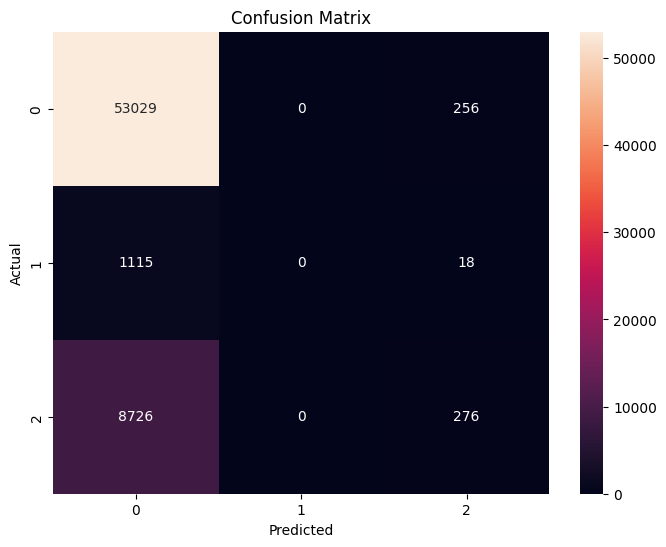

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_dt, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
#